# 신용카드 고객 이탈 예측 프로젝트
## EDA (탐색적 데이터 분석)
데이터: `bankchurners_clean.csv` (1단계 정제 완료본)

목표: 이탈률 확인, 주요 변수의 분포와 이탈 여부에 따른 차이 확인

## 0. 라이브러리 & 데이터 로드

In [2]:
import pandas as pd
import matplotlib.pyplot as plt


plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

plt.rcParams['figure.figsize'] = (7, 4)

df = pd.read_csv("../data/processed/bankchurners_clean.csv")
df.head()

,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Target
0,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0
1,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0
2,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0
3,40,F,4,High School,Unknown,Less than $40K,Blue,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0
4,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0


## 1. 전체 이탈률 확인

유지(0): 83.9%
이탈(1): 16.1%


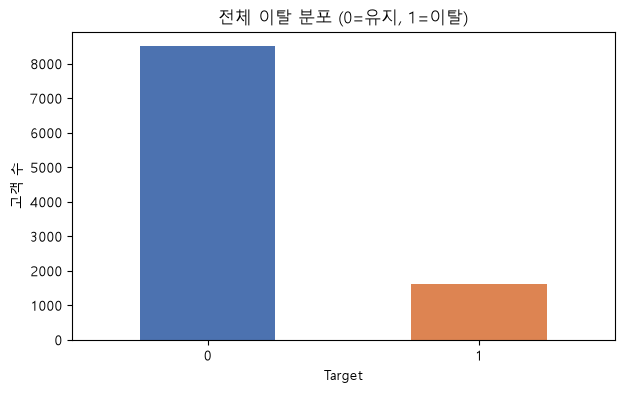

In [3]:
churn_rate = df["Target"].value_counts(normalize=True) * 100
print(f"유지(0): {churn_rate[0]:.1f}%")
print(f"이탈(1): {churn_rate[1]:.1f}%")

df["Target"].value_counts().plot(
    kind="bar", color=["#4C72B0", "#DD8452"], rot=0,
    title="전체 이탈 분포 (0=유지, 1=이탈)"
)
plt.ylabel("고객 수")
plt.show()

## 2. 범주형 변수별 이탈률
성별, 카드등급, 소득구간에 따라 이탈률에 차이가 있는지 확인.

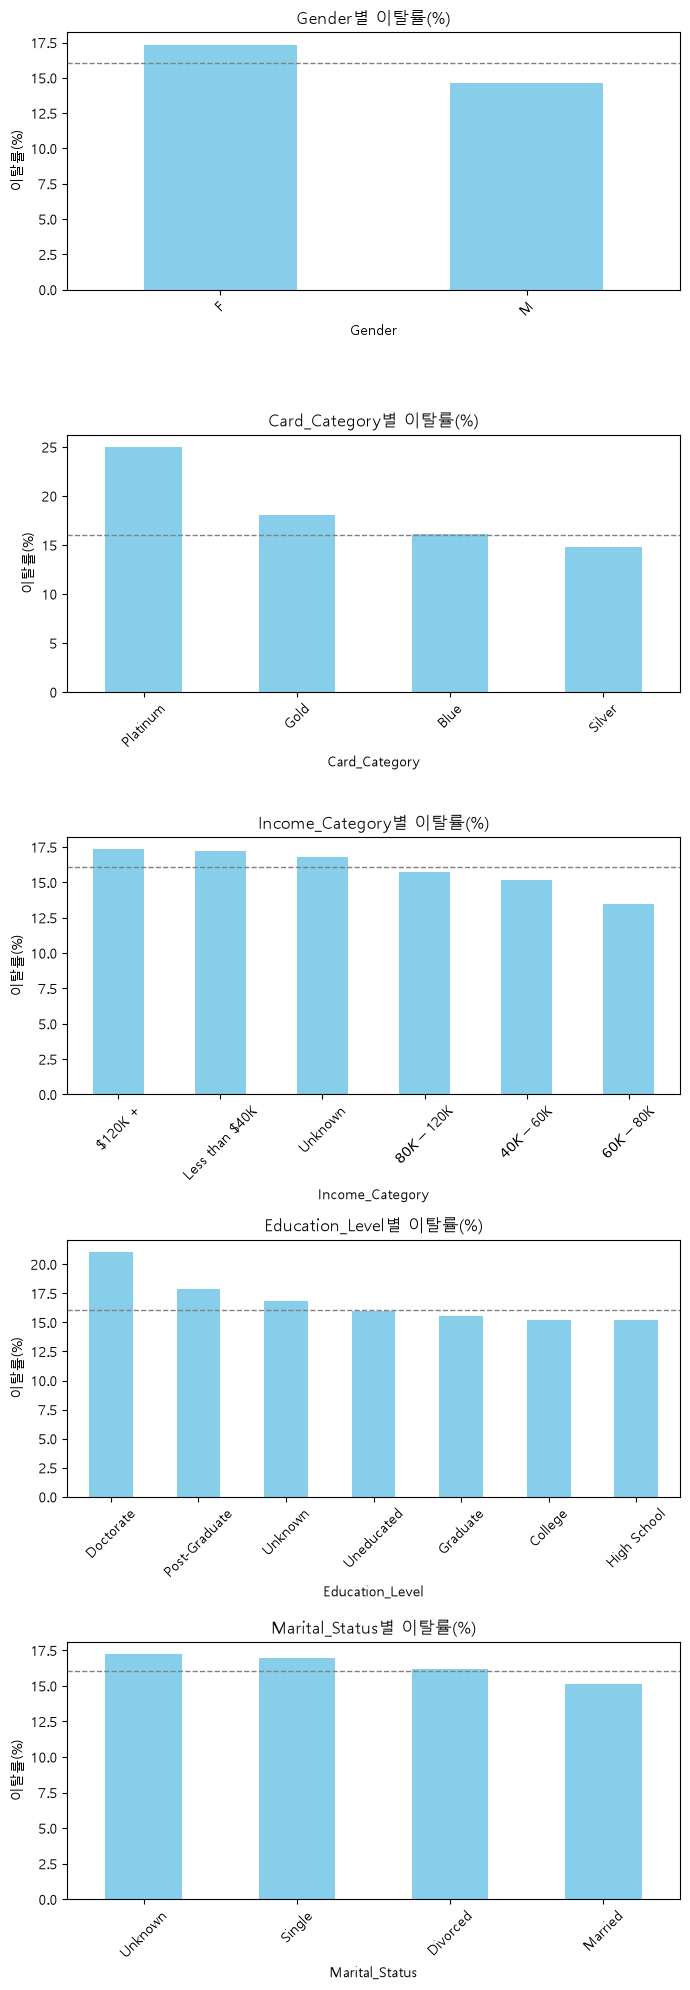

In [8]:
cat_cols = ["Gender", "Card_Category", "Income_Category", "Education_Level", "Marital_Status"]

fig, axes = plt.subplots(len(cat_cols), 1, figsize=(7, 4 * len(cat_cols)))

for ax, col in zip(axes, cat_cols):
    rate = df.groupby(col)["Target"].mean().sort_values(ascending=False) * 100
    rate.plot(kind="bar", ax=ax, color="skyblue", rot=45)
    ax.set_title(f"{col}별 이탈률(%)")
    ax.set_ylabel("이탈률(%)")
    ax.axhline(df['Target'].mean() * 100, color="gray", linestyle="--", linewidth=1)

plt.tight_layout()
plt.show()

# 범주형 변수별 이탈률(%)

전체 평균 이탈률(16.1%)을 기준선(점선)으로, 이보다 높은 그룹이 상대적으로 이탈 위험이 높은 그룹

## 1. 성별(Gender)

| 그룹 | 이탈률 | 평균 대비 |
|---|---|---|
| F (여성) | 약 17.5% | 🔴 평균보다 높음 |
| M (남성) | 약 14.7% | 🔵 평균보다 낮음 |

## 2. 카드 등급(Card_Category)

| 그룹 | 이탈률 | 평균 대비 |
|---|---|---|
| Platinum | 약 25.0% | 🔴 평균보다 훨씬 높음 (가장 위험) |
| Gold | 약 18.0% | 🔴 평균보다 높음 |
| Blue | 약 16.0% | ⚪ 평균과 비슷 |
| Silver | 약 14.8% | 🔵 평균보다 낮음 |

## 3. 소득 구간(Income_Category)

| 그룹 | 이탈률 | 평균 대비 |
|---|---|---|
| $120K + | 약 17.3% | 🔴 평균보다 높음 |
| Less than $40K | 약 17.1% | 🔴 평균보다 높음 |
| Unknown | 약 16.8% | 🔴 평균보다 소폭 높음 |
| $80K - $120K | 약 15.8% | 🔵 평균보다 낮음 |
| $40K - $60K | 약 15.2% | 🔵 평균보다 낮음 |
| $60K - $80K | 약 13.5% | 🔵 평균보다 가장 낮음 |

## 4. 학력(Education_Level)

| 그룹  | 이탈률 | 평균 대비 |
|---|---|---|
| Doctorate (박사) | 약 21.0% | 🔴 평균보다 훨씬 높음 (가장 위험) |
| Post-Graduate (대학원 이상) | 약 17.8% | 🔴 평균보다 높음 |
| Unknown (미상) | 약 16.8% | 🔴 평균보다 소폭 높음 |
| Uneducated (무학) | 약 16.0% | ⚪ 평균과 비슷 |
| Graduate (대졸) | 약 15.5% | 🔵 평균보다 낮음 |
| College (대학 재학/전문대) | 약 15.2% | 🔵 평균보다 낮음 |
| High School (고졸) | 약 15.1% | 🔵 평균보다 낮음 |

## 5. 결혼 상태(Marital_Status)

| 그룹 | 이탈률 | 평균 대비 |
|---|---|---|
| Unknown (미상) | 약 17.2% | 🔴 평균보다 높음 |
| Single (미혼) | 약 16.8% | 🔴 평균보다 소폭 높음 |
| Divorced (이혼) | 약 16.1% | ⚪ 평균과 거의 동일 |
| Married (기혼) | 약 15.1% | 🔵 평균보다 낮음 |

---

## 한눈에 보는 핵심 요약

**이탈 위험이 뚜렷하게 높은 그룹**
- **Platinum 카드** 보유자 (25.0%) — 가장 뚜렷한 차이
- **Doctorate(박사) 학력자** (21.0%) — 두 번째로 뚜렷한 차이
- 여성, 미혼/Unknown 결혼상태

**흥미로운 점**
- 고급 카드(Platinum, Gold)일수록 오히려 이탈률이 높다는 점은 직관과 다소 반대되는 결과예요. 프리미엄 고객일수록 눈높이가 높아 작은 불만에도 민감하거나, 경쟁사의 공격적인 VIP 유치 대상이 되기 쉬운 것으로 해석
- 소득/학력 모두 극단값(최고 또는 최저)에서 이탈률이 다소 높고, 중간대(Graduate, $60K~80K)에서 가장 안정적인 U자형 패턴

**전반적으로 편차가 크지 않은 변수**
- 성별, 결혼상태는 최대-최소 차이가 2~3%p 수준으로 카드등급·학력만큼 뚜렷하지 않음

## 3. 핵심 수치형 변수의 분포 (이탈 여부별 비교)
거래건수, 거래금액, 한도소진율, 비활성개월수, 문의횟수를 이탈 여부(0/1)로 나눠 비교.

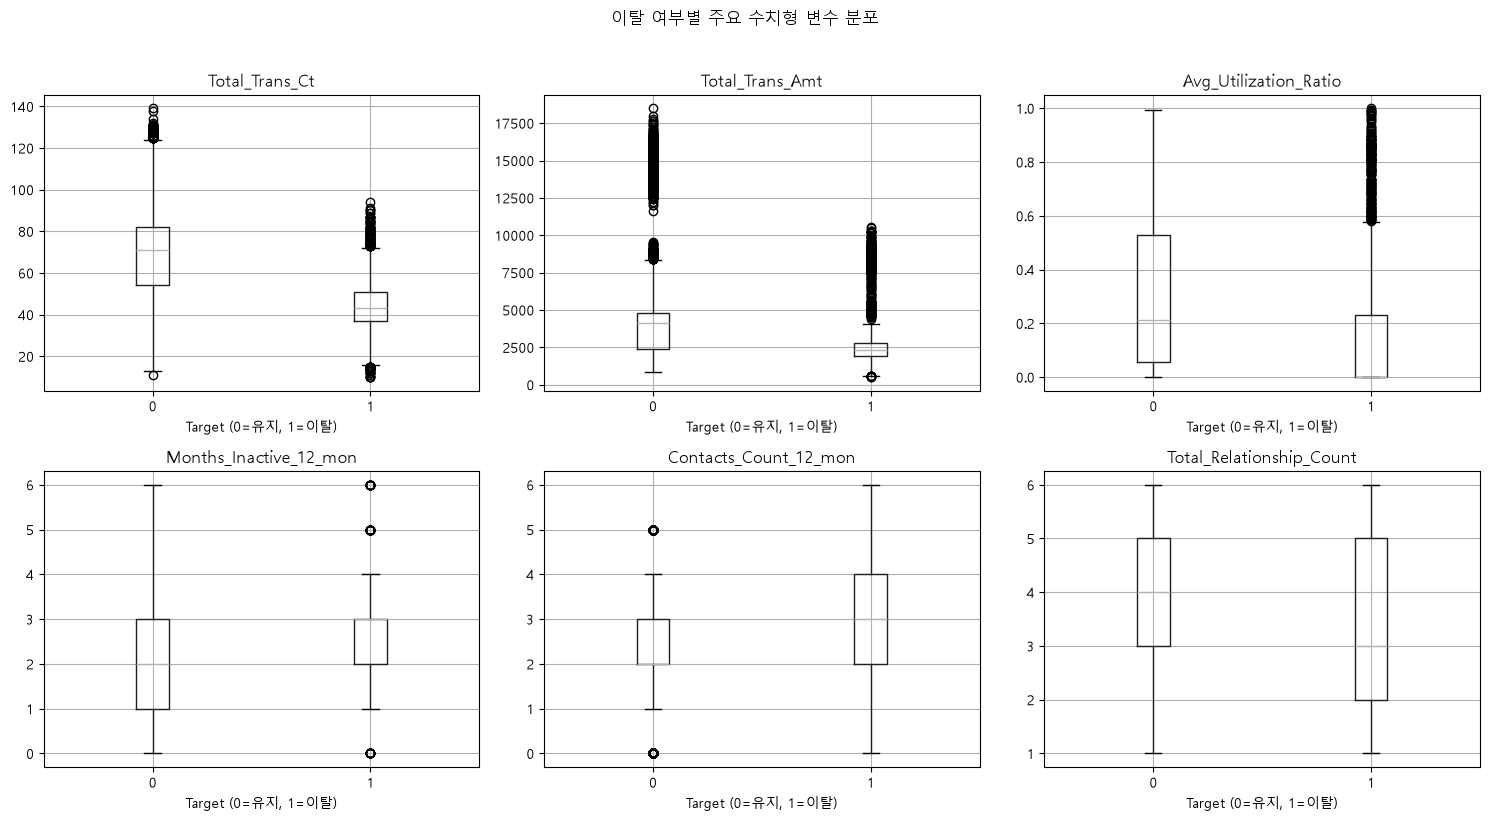

In [5]:
numeric_cols = [
    "Total_Trans_Ct", "Total_Trans_Amt", "Avg_Utilization_Ratio",
    "Months_Inactive_12_mon", "Contacts_Count_12_mon", "Total_Relationship_Count",
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, col in zip(axes, numeric_cols):
    df.boxplot(column=col, by="Target", ax=ax)
    ax.set_title(col)
    ax.set_xlabel("Target (0=유지, 1=이탈)")

plt.suptitle("이탈 여부별 주요 수치형 변수 분포", y=1.02)
plt.tight_layout()
plt.show()

## 4. 수치형 변수와 이탈 간 상관관계

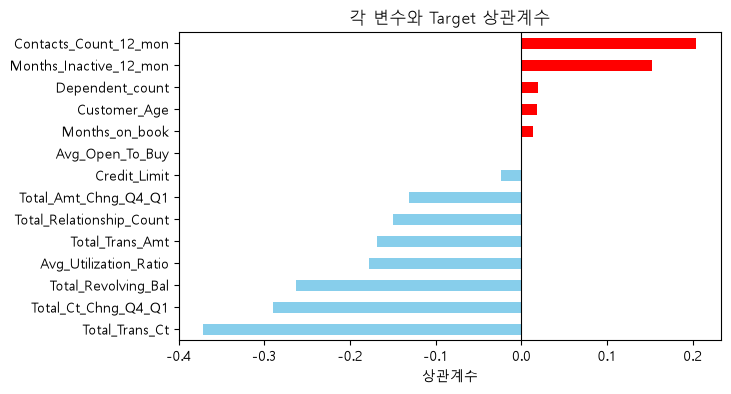

Total_Trans_Ct             -0.371403
Total_Ct_Chng_Q4_Q1        -0.290054
Total_Revolving_Bal        -0.263053
Avg_Utilization_Ratio      -0.178410
Total_Trans_Amt            -0.168598
Total_Relationship_Count   -0.150005
Total_Amt_Chng_Q4_Q1       -0.131063
Credit_Limit               -0.023873
Avg_Open_To_Buy            -0.000285
Months_on_book              0.013687
Customer_Age                0.018203
Dependent_count             0.018991
Months_Inactive_12_mon      0.152449
Contacts_Count_12_mon       0.204491
Name: Target, dtype: float64

In [6]:
import numpy as np

corr = df.select_dtypes(include="number").corr()["Target"].drop("Target").sort_values()

corr.plot(kind="barh", color=np.where(corr > 0,'red', "skyblue"))
plt.title("각 변수와 Target 상관계수")
plt.xlabel("상관계수")
plt.axvline(0, color="black", linewidth=0.8)
plt.show()

corr

# 신용카드 이탈과 각 변수의 상관관계

| 컬럼명 | 설명 | 상관계수 | 방향 |
|---|---|---|---|
| Contacts_Count_12_mon | 최근 12개월 고객센터 문의 횟수 | **+0.20** | 🔴 이탈과 양의 상관 (문의 많을수록 이탈↑) |
| Months_Inactive_12_mon | 최근 12개월 중 비활성 개월 수 | **+0.15** | 🔴 이탈과 양의 상관 (비활성 길수록 이탈↑) |
| Dependent_count | 부양가족 수 | +0.02 | 🔴 거의 무관 |
| Customer_Age | 고객 나이 | +0.02 | 🔴 거의 무관 |
| Months_on_book | 카드 보유 개월 수 | +0.01 | 🔴 거의 무관 |
| Avg_Open_To_Buy | 평균 이용 가능 한도 | 0.00 | ⚪ 무관 |
| Credit_Limit | 신용한도 | -0.02 | 🔵 거의 무관 |
| Total_Amt_Chng_Q4_Q1 | 1분기 대비 4분기 거래금액 변화율 | -0.13 | 🔵 이탈과 음의 상관 |
| Total_Relationship_Count | 보유 상품(계좌·서비스) 개수 | -0.15 | 🔵 이탈과 음의 상관 (상품 적을수록 이탈↑) |
| Total_Trans_Amt | 최근 12개월 총 거래금액 | -0.17 | 🔵 이탈과 음의 상관 |
| Avg_Utilization_Ratio | 평균 한도소진율 | -0.18 | 🔵 이탈과 음의 상관 |
| Total_Revolving_Bal | 리볼빙(이월) 잔액 | -0.26 | 🔵 이탈과 음의 상관 |
| Total_Ct_Chng_Q4_Q1 | 1분기 대비 4분기 거래건수 변화율 | -0.29 | 🔵 이탈과 음의 상관 |
| Total_Trans_Ct | 최근 12개월 총 거래건수 | **-0.37** | 🔵 **가장 강한 상관** (거래건수 적을수록 이탈↑) |

---



## 핵심 요약

**이탈 위험을 높이는 요인 (양의 상관)**
- 고객센터 문의가 잦을수록 (불만 누적 신호)
- 최근 비활성 기간이 길수록 (사용 감소 신호)

**이탈 위험을 낮추는 요인 (음의 상관, 절댓값 클수록 강함)**
- 거래건수가 많을수록 → **가장 강력한 억제 요인**
- 거래건수 변화율이 안정적일수록
- 리볼빙 잔액이 있을수록 (오히려 활발한 이용 신호로 해석 가능)
- 보유 상품 수가 많을수록 (관계가 깊을수록 이탈 어려움)

**거의 영향 없는 요인**
- 나이, 부양가족 수, 카드 보유기간, 신용한도, 평균 이용가능한도

## 5. 요약
위 결과를 바탕으로 확인할 점:
- 상관계수 절댓값이 가장 큰 변수 상위 3~5개가 이탈에 가장 큰 영향을 줄 가능성이 높음
- Boxplot에서 이탈(1) 그룹의 중앙값이 유지(0) 그룹과 뚜렷이 다른 변수를 주목
- 범주형 변수 중 평균선(점선)보다 확연히 높은 그룹은 리텐션 우선순위 후보

In [7]:
top_corr = corr.abs().sort_values(ascending=False).head(5)
print("이탈과 상관관계가 가장 큰 변수 Top 5:")
print(top_corr)

이탈과 상관관계가 가장 큰 변수 Top 5:
Total_Trans_Ct           0.371403
Total_Ct_Chng_Q4_Q1      0.290054
Total_Revolving_Bal      0.263053
Contacts_Count_12_mon    0.204491
Avg_Utilization_Ratio    0.178410
Name: Target, dtype: float64


# 이탈과 상관관계가 가장 큰 변수 Top 5

| 순위 | 변수명 (한글 설명) | 상관계수(절댓값) |
|---|---|---|
| 1 | Total_Trans_Ct (최근 12개월 총 거래건수) | 0.371 |
| 2 | Total_Ct_Chng_Q4_Q1 (1분기 대비 4분기 거래건수 변화율) | 0.290 |
| 3 | Total_Revolving_Bal (리볼빙·이월 잔액) | 0.263 |
| 4 | Contacts_Count_12_mon (최근 12개월 고객센터 문의 횟수) | 0.204 |
| 5 | Avg_Utilization_Ratio (평균 한도소진율) | 0.178 |

## 요약
- 거래건수(Total_Trans_Ct)가 이탈 예측에서 가장 강력한 단일 신호로 확인.
- 1~3위 모두 **거래 활동성·이용 규모**와 관련된 변수라, "카드를 얼마나 활발히 쓰는가"가 이탈 여부를 가르는 핵심 축.
- 4위(고객센터 문의)는 유일하게 **양의 상관**(문의가 많을수록 이탈 위험 증가)이라는 점에서, 불만 관리 측면의 인사이트로 따로 주목할 만함.



위 정보들로 할수있을만한 실제 카드사 개선점

## 1. 거래건수 감소 조기경보 시스템 (Total_Trans_Ct)
- **월별 거래건수 추적**: 최근 3개월 거래건수가 이전 대비 일정 % 이상 떨어지면 자동으로 "위험 신호" 플래그 (분류)
- **넛지 알림**: 거래건수가 줄어든 고객에게 "이번 달 카드 사용 시 캐시백 2배" 같은 간단한 재활성화 오퍼 발송 (회귀 — 예상 반등 거래건수를 예측해 오퍼 규모 결정)

## 2. 거래건수 변화율(Total_Ct_Chng_Q4_Q1)을 활용한 "타이밍" 잡기
- 절대 거래건수보다 **변화율**이 2위라는 건, "원래 많이 안 쓰던 사람"보다 "갑자기 덜 쓰기 시작한 사람"을 잡아내는 게 더 중요 (분류 — 급감 여부를 Yes/No로 플래그)
- **분기별 변화율 기반 그룹**을 만들어서, 변화율이 급격히 떨어지는 시점에 바로 개입 (군집 — 변화율 패턴이 비슷한 고객끼리 묶어 "급감형/완만감소형/안정형"으로 세분화)

## 3. 리볼빙 잔액(Total_Revolving_Bal)의 이중적 해석 활용
- 리볼빙 잔액이 있는 고객과 없는 고객을 나눠 이탈 위험을 비교 (분류 — 잔액 유무를 임계값 기준으로 이진화해 위험군 판별)
- 잔액 수준별로 예상 이탈 확률이 어떻게 달라지는지 곡선으로 추정 (회귀 — 잔액 금액을 연속값으로 넣어 이탈확률과의 관계를 곡선으로 추정)
- 잔액 규모·이용 패턴이 비슷한 고객끼리 묶어 "락인형/완납형/미이용형"으로 분류 (군집)

## 4. 고객센터 문의 횟수(Contacts_Count_12_mon) — 유일한 "불만 신호"
- 문의 3회 이상인 고객을 자동으로 VOC 우선 검토 대상으로 지정 (분류 — 임계값 기반 이진 판별)
- 문의 횟수가 늘어날수록 이탈확률이 몇 %p씩 증가하는지 정량적으로 추정 (회귀 — 문의횟수를 연속 변수로 넣어 이탈확률 변화폭 계산)
- 문의 횟수와 문의 후 대응(해결/미해결) 패턴이 비슷한 고객군을 묶어 "불만 미해결 위험군/단순 문의형"으로 구분 (군집)

## 5. 한도소진율(Avg_Utilization_Ratio) 기반 그룹 분리
- 한도소진율이 특정 구간(예: 5% 미만) 이하인 고객을 "동면 고객"으로 자동 분류 (분류)
- 한도소진율 수준별 예상 카드 이용금액(LTV)을 추정해 우량 고객 스코어링에 반영 (회귀)
- 한도소진율 + 거래건수를 함께 활용해 "활동형/동면형/과다이용형" 등으로 고객군 나누기 (군집)

---

## 종합

| 그룹 | 조건 | 액션 |
|---|---|---|
| 즉시 개입 | 거래건수 급감 + 변화율 마이너스 + 문의 3회 이상 | 전담 상담 + 즉시 혜택 오퍼 |
| 재활성화 대상 | 리볼빙 잔액 0 + 한도소진율 낮음 | 캐시백/포인트 상향 캠페인 |
| 안정 관리 | 리볼빙 잔액 있음 + 거래건수 꾸준 | 별도 개입 불필요, 일반 유지 |


## 정리

| 변수 | 분류(Classification) | 회귀(Regression) | 군집(Clustering) |
|---|---|---|---|
| 거래건수 | 급감 여부 Yes/No | 예상 반등 거래건수 예측 | - |
| 거래건수 변화율 | 급감 여부 플래그 | - | 변화 패턴별 그룹화 |
| 리볼빙 잔액 | 잔액 유무 이진 판별 | 잔액 수준-이탈확률 관계 추정 | 이용 유형별 그룹화 |
| 문의 횟수 | 임계값 기반 위험군 판별 | 문의 1회당 이탈확률 증가폭 추정 | 불만 유형별 그룹화 |
| 한도소진율 | 동면 고객 판별 | 예상 LTV 추정 | 활동성 기반 그룹화 |




